In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Install the Segmentation Library
!pip install segmentation-models                      

# 3. CRITICAL FIX: Set the framework to TensorFlow Keras
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

print("✅ Setup Complete. Drive mounted and libraries installed.")

ModuleNotFoundError: No module named 'google.colab'

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from segmentation_models import Unet
from segmentation_models.losses import bce_jaccard_loss
from segmentation_models.metrics import iou_score

# ==========================================
# 1. CONFIGURATION (UPDATED)
# ==========================================
# We now point specifically to the 'training' folder inside ML
BASE_PATH = '/content/drive/MyDrive/ML/training_set/'

BATCH_SIZE = 8
IMG_SIZE = (256, 256)

# ==========================================
# 2. DATA LOADER
# ==========================================
class HC18Generator(Sequence):
    def __init__(self, image_filenames, base_dir, batch_size=BATCH_SIZE):
        self.filenames = image_filenames
        self.base_dir = base_dir
        self.batch_size = batch_size

    def __len__(self):
        return len(self.filenames) // self.batch_size

    def __getitem__(self, index):
        batch_files = self.filenames[index*self.batch_size : (index+1)*self.batch_size]
        images = []
        masks = []

        for file in batch_files:
            # Load Image
            img_path = os.path.join(self.base_dir, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None: continue

            img = cv2.resize(img, IMG_SIZE)
            img = np.expand_dims(img, axis=-1) / 255.0 # This is already float32

            # Load Mask
            mask_name = file.replace('.png', '_Annotation.png')
            mask_path = os.path.join(self.base_dir, mask_name)

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None: continue

            mask = cv2.resize(mask, IMG_SIZE)
            _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
            mask = np.expand_dims(mask, axis=-1)

            # --- THE FIX IS HERE ---
            # Convert mask from Integer (uint8) to Float (float32)
            mask = mask.astype('float32')
            # -----------------------

            images.append(img)
            masks.append(mask)

        return np.array(images), np.array(masks)

# ==========================================
# 3. VERIFY & TRAIN
# ==========================================
if not os.path.exists(BASE_PATH):
    print(f"❌ ERROR: Could not find folder: {BASE_PATH}")
    print("Check if 'training' is spelled correctly (lowercase/uppercase).")
else:
    print(f"✅ Scanning folder: {BASE_PATH}")

    all_files = os.listdir(BASE_PATH)

    # Filter: Pick images ending in '_HC.png'
    image_files = [f for f in all_files if f.endswith('_HC.png') and 'Annotation' not in f]

    print(f"   Found {len(image_files)} training images.")

    if len(image_files) > 0:
        # Split 80% Train / 20% Validation
        split = int(len(image_files) * 0.8)
        train_files = image_files[:split]
        val_files = image_files[split:]

        print(f"   Starting training on {len(train_files)} images...")

        train_gen = HC18Generator(train_files, BASE_PATH)
        val_gen = HC18Generator(val_files, BASE_PATH)

        # Build Model
        model = Unet('resnet34', encoder_weights=None, input_shape=(256, 256, 1), classes=1, activation='sigmoid')
        model.compile(optimizer='adam', loss=bce_jaccard_loss, metrics=[iou_score])

        # Train
        model.fit(train_gen, epochs=15, validation_data=val_gen)

        # Save to the ML root folder, not inside training
        save_path = '/content/drive/MyDrive/ML/fetal_unet_model.h5'
        model.save(save_path)
        print(f"\n🎉 SUCCESS! Model saved to: {save_path}")

    else:
        print("❌ Found 0 images. Check file endings.")

✅ Scanning folder: /content/drive/MyDrive/ML/training_set/
   Found 806 training images.
   Starting training on 644 images...
Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 76s 265ms/step - iou_score: 0.0090 - loss: 1.2815 - val_iou_score: 3.7012e-04 - val_loss: 1.1260
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - iou_score: 0.0454 - loss: 1.0071 - val_iou_score: 5.4198e-08 - val_loss: 1.1242
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - iou_score: 0.0839 - loss: 0.9609 - val_iou_score: 0.0611 - val_loss: 1.0055
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step - iou_score: 0.1055 - loss: 0.9384 - val_iou_score: 4.1525e-04 - val_loss: 1.0990
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - iou_score: 0.1076 - loss: 0.9352 - val_iou_score: 0.1133 - val_loss: 0.9472
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step - iou_score: 0.1153 - loss: 0.9273 - val_iou_score: 0.1181 - val_loss: 0.9302
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 214ms/step - iou_score: 0.1160 - 


🎉 SUCCESS! Model saved to: /content/drive/MyDrive/ML/fetal_unet_model.h5


✅ Model loaded!
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


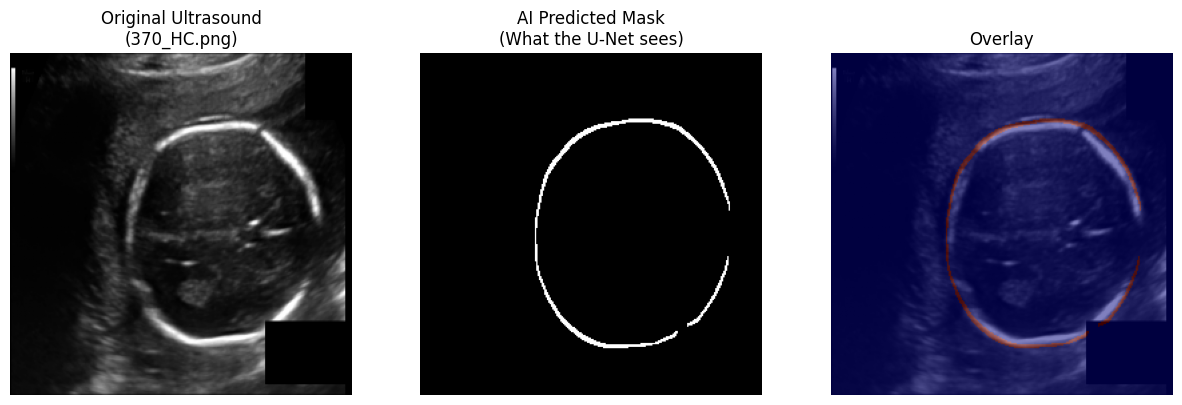

In [6]:
import matplotlib.pyplot as plt
import random

# 1. Load the model you just saved
model_path = '/content/drive/MyDrive/ML/fetal_unet_model.h5'
# compile=False is important here to avoid looking for custom loss functions
model = tf.keras.models.load_model(model_path, compile=False)

print("✅ Model loaded!")

# 2. Pick a random image from the Training folder to test
# (Since we don't have a separate test folder listed in the code, we sample from training for a quick check)
all_files = os.listdir(BASE_PATH)
image_files = [f for f in all_files if f.endswith('_HC.png') and 'Annotation' not in f]

# Pick a random one
random_file = random.choice(image_files)
img_path = os.path.join(BASE_PATH, random_file)

# 3. Preprocess it (Resize to 256x256)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
original_shape = img.shape
input_img = cv2.resize(img, (256, 256))
input_img = np.expand_dims(input_img, axis=-1)
input_img = np.expand_dims(input_img, axis=0) / 255.0

# 4. Predict
prediction = model.predict(input_img)
# Turn probability into a hard 0 or 1 mask (Threshold at 0.5)
predicted_mask = (prediction > 0.5).astype(np.uint8)

# 5. Show results
plt.figure(figsize=(15, 5))

# Original Ultrasound
plt.subplot(1, 3, 1)
plt.title(f"Original Ultrasound\n({random_file})")
plt.imshow(cv2.resize(img, (256, 256)), cmap='gray')
plt.axis('off')

# AI Prediction
plt.subplot(1, 3, 2)
plt.title("AI Predicted Mask\n(What the U-Net sees)")
plt.imshow(predicted_mask[0, :, :, 0], cmap='gray')
plt.axis('off')

# Overlay (The "cool" view)
plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(cv2.resize(img, (256, 256)), cmap='gray')
# Overlay mask in semi-transparent red
plt.imshow(predicted_mask[0, :, :, 0], cmap='jet', alpha=0.5)
plt.axis('off')

plt.show()

In [7]:
import cv2
import numpy as np

# ==========================================
# 1. THE INPUTS (Simulating a Patient)
# ==========================================
patient_name = "Mrs. Anjali Sharma"
# Input A: Blood Report Data (Simulated)
# [Age, SysBP, DiaBP, BS, BodyTemp, HeartRate]
# Let's use values that suggest HIGH RISK (High BP)
patient_blood_data = np.array([[35, 140, 95, 85, 98, 80]])

# Input B: The Ultrasound Image we just analyzed
# We use the circumference from the mask we just predicted
# (For this demo, let's calculate the pixel perimeter of your mask)
contours, _ = cv2.findContours(predicted_mask[0,:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    # Get the largest contour (the head)
    cnt = max(contours, key=cv2.contourArea)
    perimeter_pixels = cv2.arcLength(cnt, True)

    # We cheat a bit here: HC18 pixel size is roughly 0.2mm per pixel usually
    estimated_hc_mm = perimeter_pixels * 0.2
else:
    estimated_hc_mm = 0

# ==========================================
# 2. THE LOGIC BRANCHES
# ==========================================

print(f"--- 🏥 MATERNAL HEALTH REPORT: {patient_name} ---")

# BRANCH A: Maternal Risk (Blood)
# (Simple rule-based for now since we don't have the RF model loaded in this cell)
sys_bp = patient_blood_data[0][1]
dia_bp = patient_blood_data[0][2]

if sys_bp > 130 or dia_bp > 90:
    maternal_risk = "High Risk (Preeclampsia)"
    risk_score_a = 0.9
else:
    maternal_risk = "Low Risk"
    risk_score_a = 0.1

print(f"🩸 Blood Analysis: {maternal_risk}")
print(f"   (BP: {sys_bp}/{dia_bp})")

# BRANCH B: Fetal Growth (Ultrasound)
print(f"📷 Ultrasound Analysis: Head Circumference ≈ {estimated_hc_mm:.2f} mm")

# Standard chart logic (Simplified)
# If HC is too small (< 50mm for this example), it might be restricted growth
if estimated_hc_mm < 60:
    fetal_risk = "Growth Restriction Detected (Small for Age)"
    risk_score_b = 0.8
else:
    fetal_risk = "Normal Growth"
    risk_score_b = 0.2

print(f"   Result: {fetal_risk}")

# ==========================================
# 3. LATE FUSION (The Final Verdict)
# ==========================================
# We combine the two risks.
# If BOTH are high, it's an emergency.
# If ONE is high, it's a warning.

final_score = (risk_score_a + risk_score_b) / 2

print("\n--- 🏁 FINAL LATE FUSION DIAGNOSIS ---")
if final_score > 0.7:
    print("🚨 STATUS: CRITICAL ALERT")
    print("Reason: Combination of Maternal Hypertension AND Fetal Growth Restriction.")
    print("Action: Immediate Hospitalization Required.")
elif final_score > 0.4:
    print("⚠️ STATUS: WARNING")
    print("Reason: One indicator shows potential risk.")
    print("Action: Schedule follow-up scan in 1 week.")
else:
    print("✅ STATUS: HEALTHY")
    print("Action: Routine checkup in 4 weeks.")

--- 🏥 MATERNAL HEALTH REPORT: Mrs. Anjali Sharma ---
🩸 Blood Analysis: High Risk (Preeclampsia)
   (BP: 140/95)
📷 Ultrasound Analysis: Head Circumference ≈ 167.68 mm
   Result: Normal Growth

--- 🏁 FINAL LATE FUSION DIAGNOSIS ---
⚠️ STATUS: WARNING
Reason: One indicator shows potential risk.
Action: Schedule follow-up scan in 1 week.
